In [1]:
import sys
print("Python:", sys.executable)

!nvidia-smi

Python: /usr/bin/python3
Thu Sep 24 08:19:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------

In [3]:
import sys
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}:", torch.cuda.get_device_name(i))

Python: /usr/bin/python3
PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [4]:
import os
import subprocess

REPO_DIR = "/kaggle/working/fashn-vton-1.5"

if not os.path.exists(REPO_DIR):
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/fashn-AI/fashn-vton-1.5.git",
            REPO_DIR
        ],
        check=True
    )
    print("FASHN VTON repository cloned successfully.")
else:
    print("Repository already exists.")

Cloning into '/kaggle/working/fashn-vton-1.5'...


FASHN VTON repository cloned successfully.


In [5]:
%cd /kaggle/working/fashn-vton-1.5

/kaggle/working/fashn-vton-1.5


In [6]:
import sys
import subprocess

REPO_DIR = "/kaggle/working/fashn-vton-1.5"

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-e",
        REPO_DIR
    ],
    check=True
)

print("FASHN VTON installation completed.")

Obtaining file:///kaggle/working/fashn-vton-1.5
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.7/246.7 MB 7.4 MB/s eta 0:00:00
  Building editable for fashn-vton (pyproject.toml): started
  Building editable for fashn-vton (pyproject.toml): finished with status 'done'
  Created wheel for fashn-vton: filename=fashn_vton-1.5.0-0.editable-py3-none-any.whl size=5777 sha256=f759da264abaf86bb27a04f48684826c9438182eb7a94d9653ba95e60a3516b1
  Stored in directory: /tmp/pip-ephem-wheel-cache-fm9nas90/wheels/

In [1]:
import sys
import importlib.util

print("Python:", sys.executable)

spec = importlib.util.find_spec("fashn_vton")

if spec is None:
    print("❌ fashn_vton is NOT installed")
else:
    print("✅ fashn_vton found at:")
    print(spec.origin)

Python: /usr/bin/python3
✅ fashn_vton found at:
/kaggle/working/fashn-vton-1.5/src/fashn_vton/__init__.py


In [2]:
from fashn_vton import TryOnPipeline

print("✅ FASHN VTON 1.5 imported successfully!")

✅ FASHN VTON 1.5 imported successfully!


In [3]:
import os

WEIGHTS_DIR = "/kaggle/working/fashn-vton-1.5/weights"

os.makedirs(WEIGHTS_DIR, exist_ok=True)

print("Weights directory:")
print(WEIGHTS_DIR)

Weights directory:
/kaggle/working/fashn-vton-1.5/weights


In [4]:
%cd /kaggle/working/fashn-vton-1.5

!python scripts/download_weights.py --weights-dir /kaggle/working/fashn-vton-1.5/weights

/kaggle/working/fashn-vton-1.5


model.safetensors: 100%|████████████████████| 1.94G/1.94G [00:13<00:00, 140MB/s]
  Saved to: /kaggle/working/fashn-vton-1.5/weights/model.safetensors

yolox_l.onnx: 100%|███████████████████████████| 217M/217M [00:01<00:00, 153MB/s]
  Saved to: /kaggle/working/fashn-vton-1.5/weights/dwpose/yolox_l.onnx
dw-ll_ucoco_384.onnx: 100%|██████████████████| 134M/134M [00:01<00:00, 83.2MB/s]
  Saved to: /kaggle/working/fashn-vton-1.5/weights/dwpose/dw-ll_ucoco_384.onnx

config.json: 1.65kB [00:00, 3.76MB/s]
model.safetensors: 100%|█████████████████████| 256M/256M [00:05<00:00, 45.6MB/s]
Loading weights: 100%|█| 930/930 [00:00<00:00, 1397.26it/s, Materializing param=
  Cached in HuggingFace hub cache

Download complete!

Weights directory structure:
    /kaggle/working/fashn-vton-1.5/weights/
    ├── model.safetensors
    └── dwpose/
        ├── yolox_l.onnx
        └── dw-ll_ucoco_384.onnx

Usage:
    from fashn_vton import TryOnPipeline
    pipeline = TryOnPipeli

In [5]:
import torch

assert torch.cuda.is_available(), "❌ CUDA GPU is not available!"

DEVICE = "cuda:0"

print("Using device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))

gpu_memory = (
    torch.cuda.get_device_properties(0).total_memory
    / (1024 ** 3)
)

print(f"GPU memory: {gpu_memory:.2f} GB")
print("BF16 supported:", torch.cuda.is_bf16_supported())

Using device: cuda:0
GPU: Tesla T4
GPU memory: 14.56 GB
BF16 supported: True


In [6]:
from fashn_vton import TryOnPipeline

print("Loading FASHN VTON pipeline...")

pipeline = TryOnPipeline(
    weights_dir=WEIGHTS_DIR,
    device=DEVICE
)

print("✅ FASHN VTON pipeline loaded successfully!")

TryOnPipeline - INFO - Using device: cuda:0
TryOnPipeline - INFO - Using dtype: torch.bfloat16
TryOnPipeline - INFO - Loading TryOnModel from /kaggle/working/fashn-vton-1.5/weights/model.safetensors


Loading FASHN VTON pipeline...


TryOnPipeline - INFO - TryOnModel loaded
TryOnPipeline - INFO - Loading DWPose from /kaggle/working/fashn-vton-1.5/weights/dwpose
2026-09-24 08:24:36.134946374 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:855 operator()] No registered plugin EP device found for 'CUDAExecutionProvider' with device_id=0
2026-09-24 08:24:36.136553023 [E:onnxruntime:Default, provider_bridge_ort.cc:2395 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1988 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /usr/local/lib/python3.12/dist-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libcublasLt.so.13: cannot open shared object file: No such file or directory

2026-09-24 08:24:36.136571379 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:1294 CreateExecutionProviderFactoryInstance] Failed to create CUDAExecutionProvider. Require cuDNN 9.* and CUDA 13.*. Please install all 

Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

TryOnPipeline - INFO - FashnHumanParser loaded


✅ FASHN VTON pipeline loaded successfully!


In [7]:
from IPython.display import display
from ipywidgets import FileUpload

upload = FileUpload(
    accept='.jpg,.jpeg,.png',
    multiple=True
)

display(upload)

FileUpload(value=(), accept='.jpg,.jpeg,.png', description='Upload', multiple=True)

In [56]:
from IPython.display import display
from ipywidgets import FileUpload

upload = FileUpload(
    accept='.jpg,.jpeg,.png',
    multiple=True
)

display(upload)

FileUpload(value=(), accept='.jpg,.jpeg,.png', description='Upload', multiple=True)

In [57]:
import os

os.makedirs("/kaggle/working", exist_ok=True)

for fileinfo in upload.value:
    filename = fileinfo["name"]
    content = fileinfo["content"]

    output_path = f"/kaggle/working/{filename}"

    with open(output_path, "wb") as f:
        f.write(content)

    print("✅ Saved:", output_path)

✅ Saved: /kaggle/working/output4.png
✅ Saved: /kaggle/working/skirt.jpg


In [58]:
PERSON_PATH = "/kaggle/working/output4.png"
GARMENT_PATH = "/kaggle/working/skirt.jpg"

print("Person:", PERSON_PATH)
print("Garment:", GARMENT_PATH)

Person: /kaggle/working/output4.png
Garment: /kaggle/working/skirt.jpg


In [59]:
import os

print("Person exists:", os.path.exists(PERSON_PATH))
print("Garment exists:", os.path.exists(GARMENT_PATH))

Person exists: True
Garment exists: True


PERSON
Mode: RGB
Size: (576, 768)

GARMENT
Mode: RGB
Size: (1179, 1725)

========== PERSON ==========


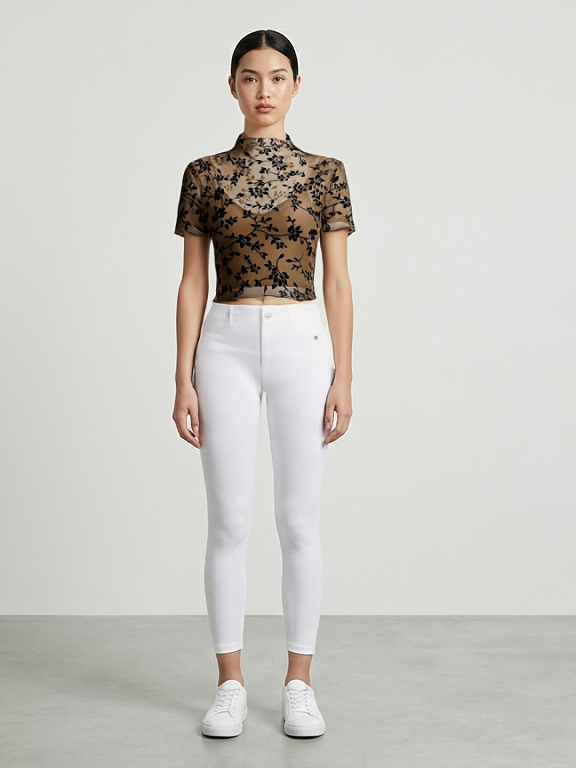


========== GARMENT ==========


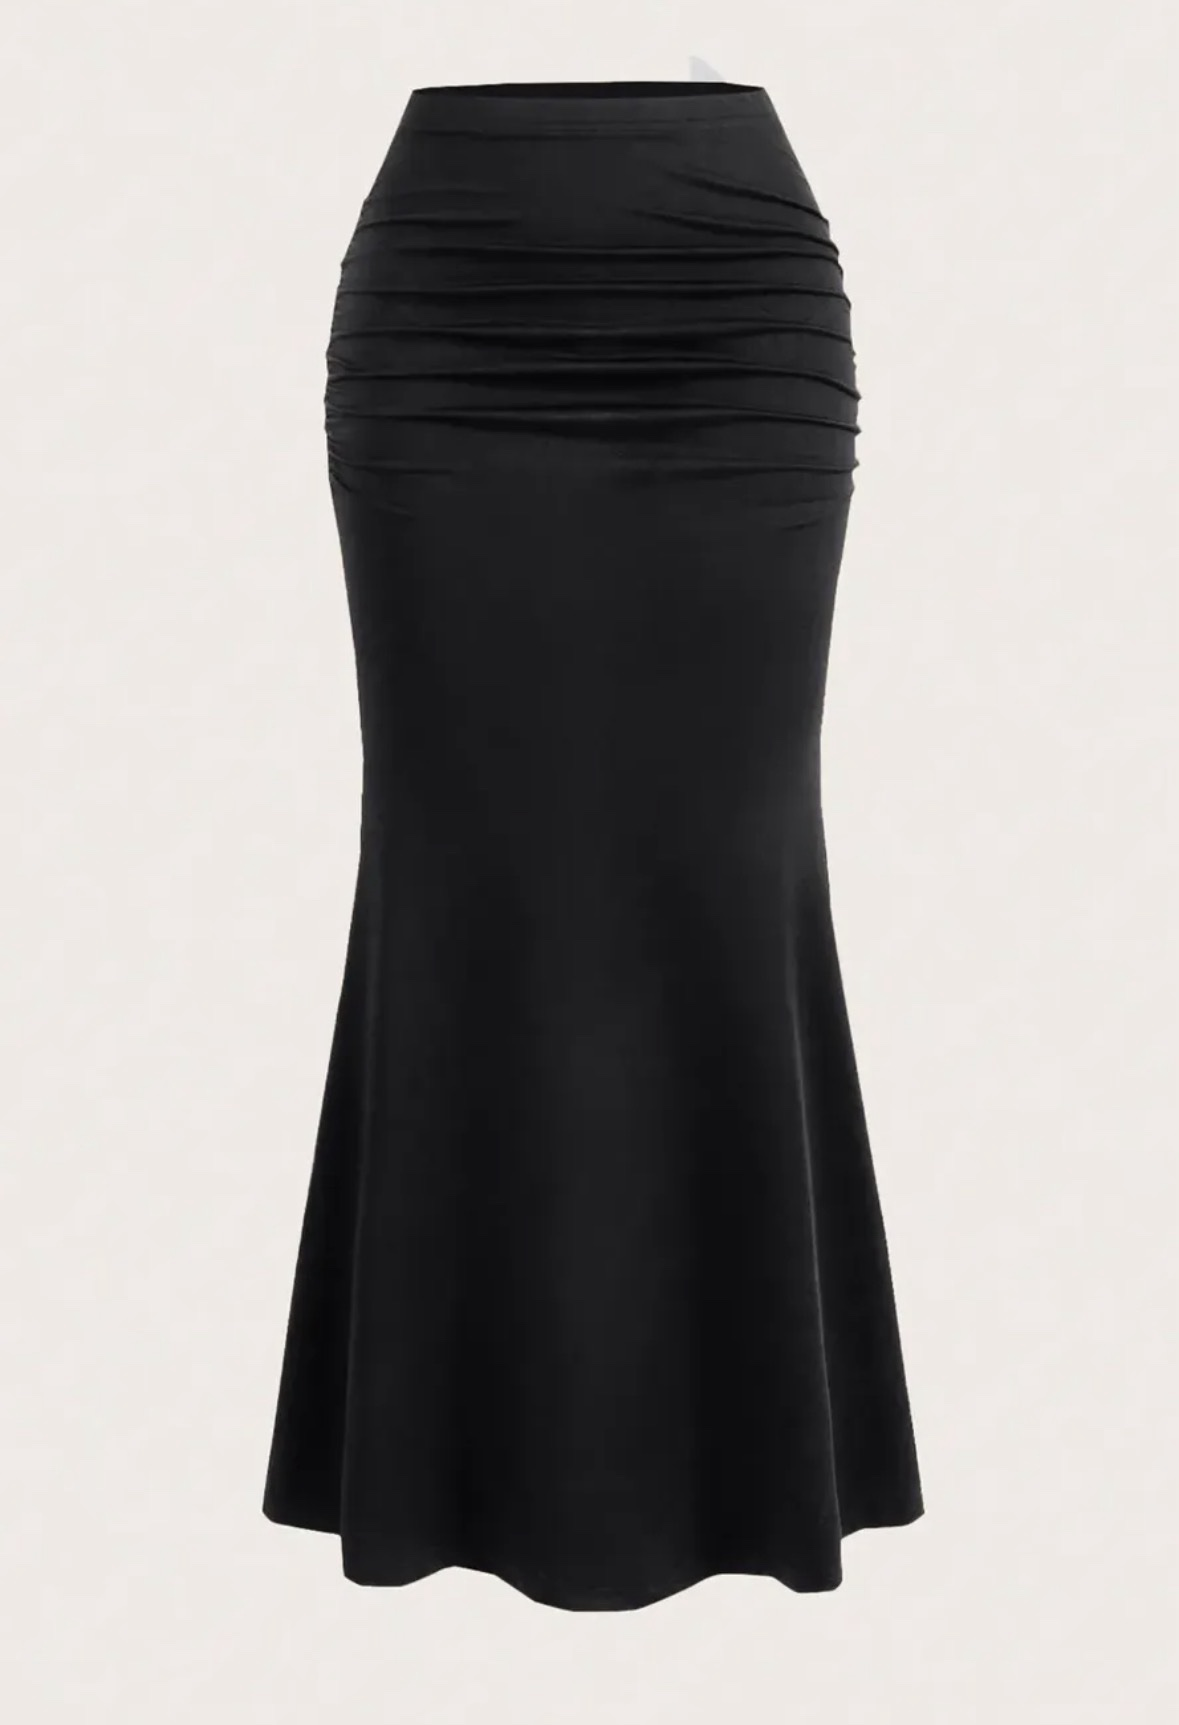

In [60]:
from PIL import Image
from IPython.display import display

person_original = Image.open(PERSON_PATH)
garment_original = Image.open(GARMENT_PATH)

print("PERSON")
print("Mode:", person_original.mode)
print("Size:", person_original.size)

print("\nGARMENT")
print("Mode:", garment_original.mode)
print("Size:", garment_original.size)

print("\n========== PERSON ==========")
display(person_original)

print("\n========== GARMENT ==========")
display(garment_original)

In [50]:
import numpy as np

garment_rgba = garment_original.convert("RGBA")

rgba = np.array(garment_rgba)

alpha = rgba[:, :, 3]

transparent_pixels = np.sum(alpha == 0)
opaque_pixels = np.sum(alpha == 255)
partial_pixels = np.sum((alpha > 0) & (alpha < 255))

total_pixels = alpha.size

print("Garment mode:", garment_rgba.mode)
print("Garment shape:", rgba.shape)

print(
    "Transparent:",
    round(transparent_pixels / total_pixels * 100, 2),
    "%"
)

print(
    "Opaque:",
    round(opaque_pixels / total_pixels * 100, 2),
    "%"
)

print(
    "Partial:",
    round(partial_pixels / total_pixels * 100, 2),
    "%"
)

Garment mode: RGBA
Garment shape: (1527, 1179, 4)
Transparent: 0.0 %
Opaque: 100.0 %
Partial: 0.0 %


In [61]:
from PIL import Image

# Keep original transparent image
garment_rgba = Image.open(GARMENT_PATH).convert("RGBA")

# Create white RGB background
white_background = Image.new(
    "RGB",
    garment_rgba.size,
    (255, 255, 255)
)

# Composite garment over white
white_background.paste(
    garment_rgba,
    mask=garment_rgba.getchannel("A")
)

# Temporary image used by FASHN
garment = white_background.convert("RGB")

print("Original garment:", garment_rgba.mode)
print("FASHN garment:", garment.mode)

Original garment: RGBA
FASHN garment: RGB


In [62]:
person = Image.open(PERSON_PATH).convert("RGB")

print("Person mode:", person.mode)
print("Person size:", person.size)

print("Garment mode:", garment.mode)
print("Garment size:", garment.size)

Person mode: RGB
Person size: (576, 768)
Garment mode: RGB
Garment size: (1179, 1725)


========== PERSON SENT TO FASHN ==========


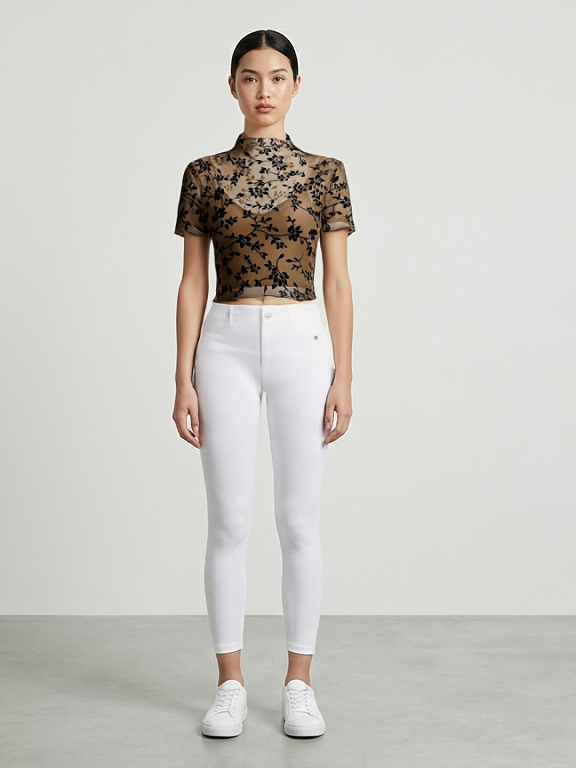

========== GARMENT SENT TO FASHN ==========


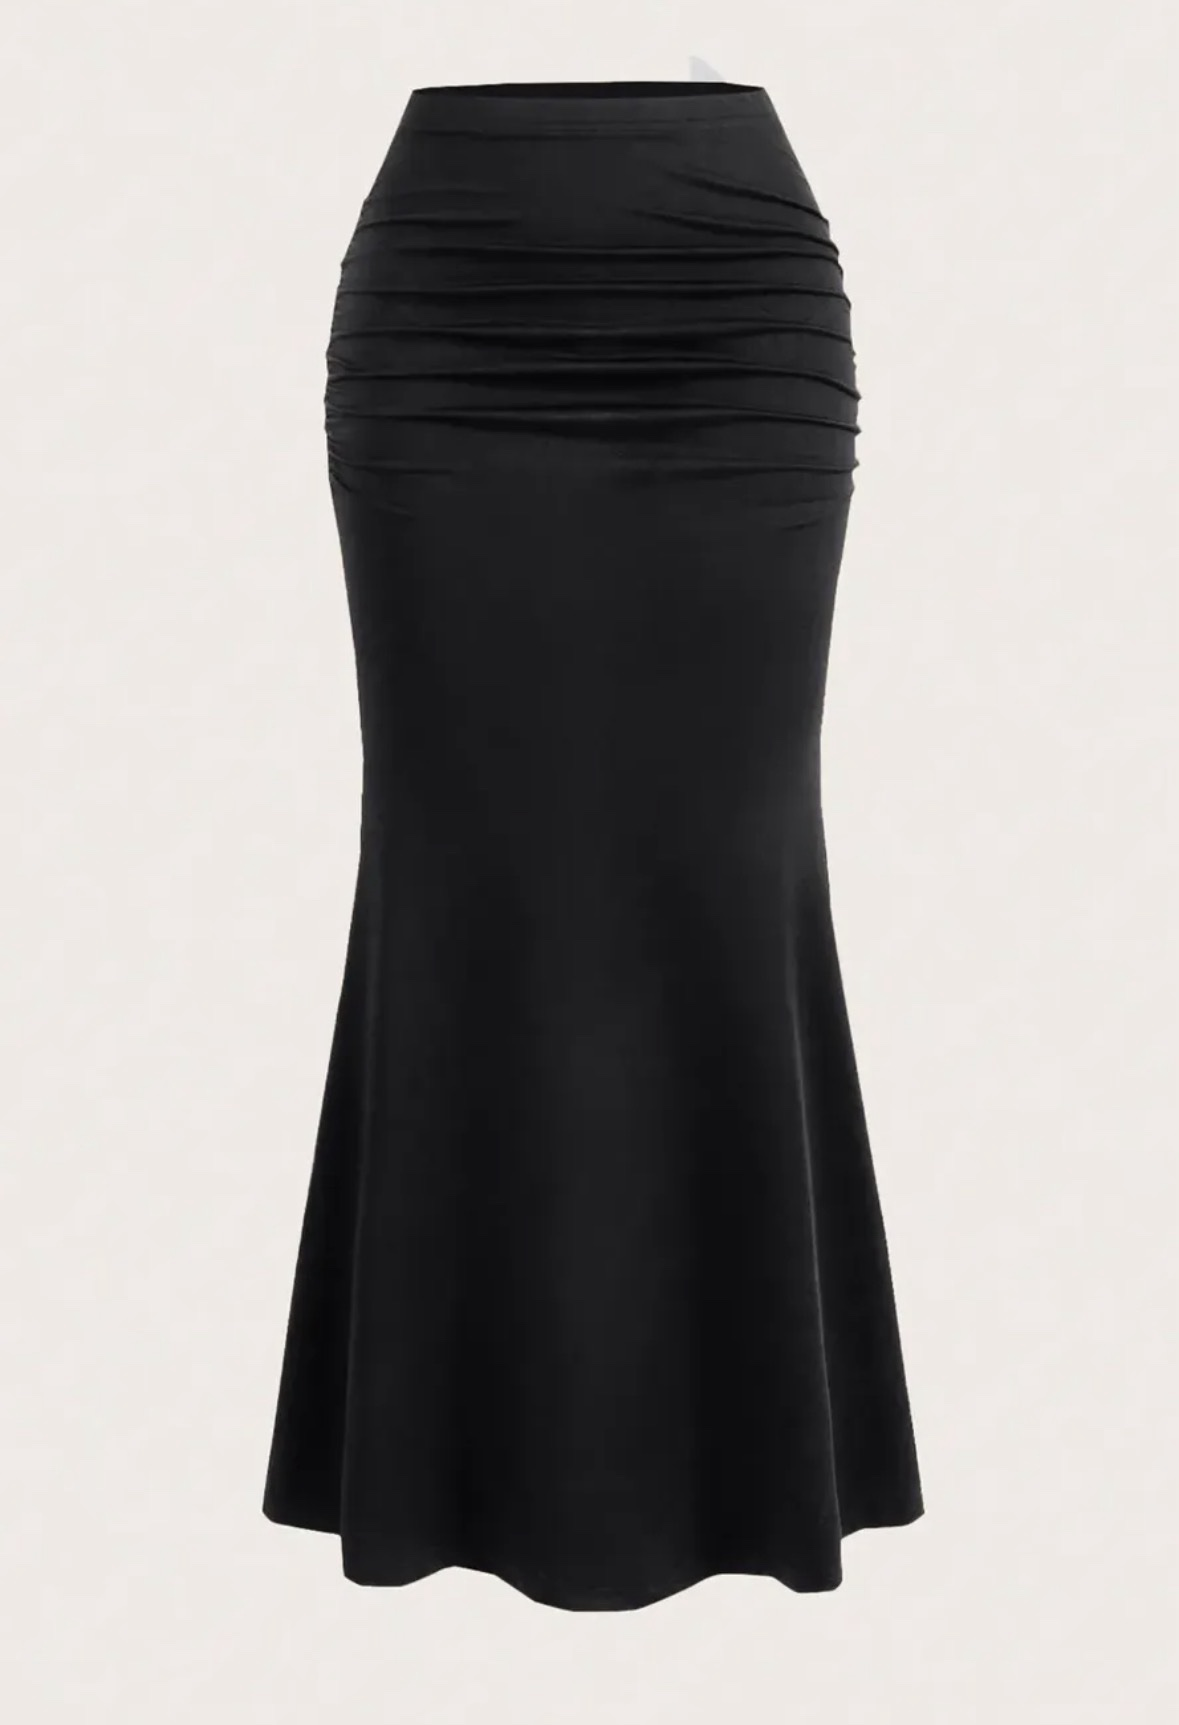

In [63]:
from IPython.display import display

print("========== PERSON SENT TO FASHN ==========")
display(person)

print("========== GARMENT SENT TO FASHN ==========")
display(garment)

========== CURRENT INPUTS ==========
Person file: /kaggle/working/output4.png
Person size: (576, 768)
Person mode: RGB

Garment file: /kaggle/working/skirt.jpg
Garment size: (1179, 1725)
Garment original mode: RGBA
Garment sent to FASHN: RGB

========== PERSON ==========


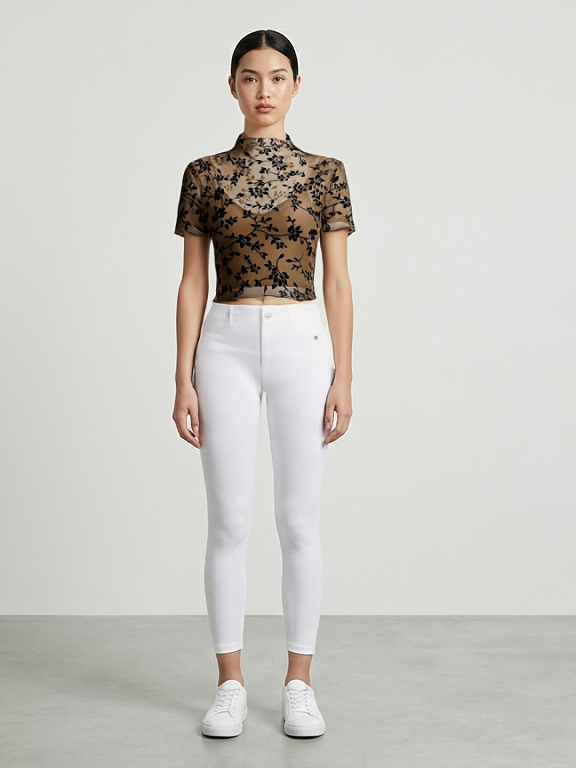


========== GARMENT ==========


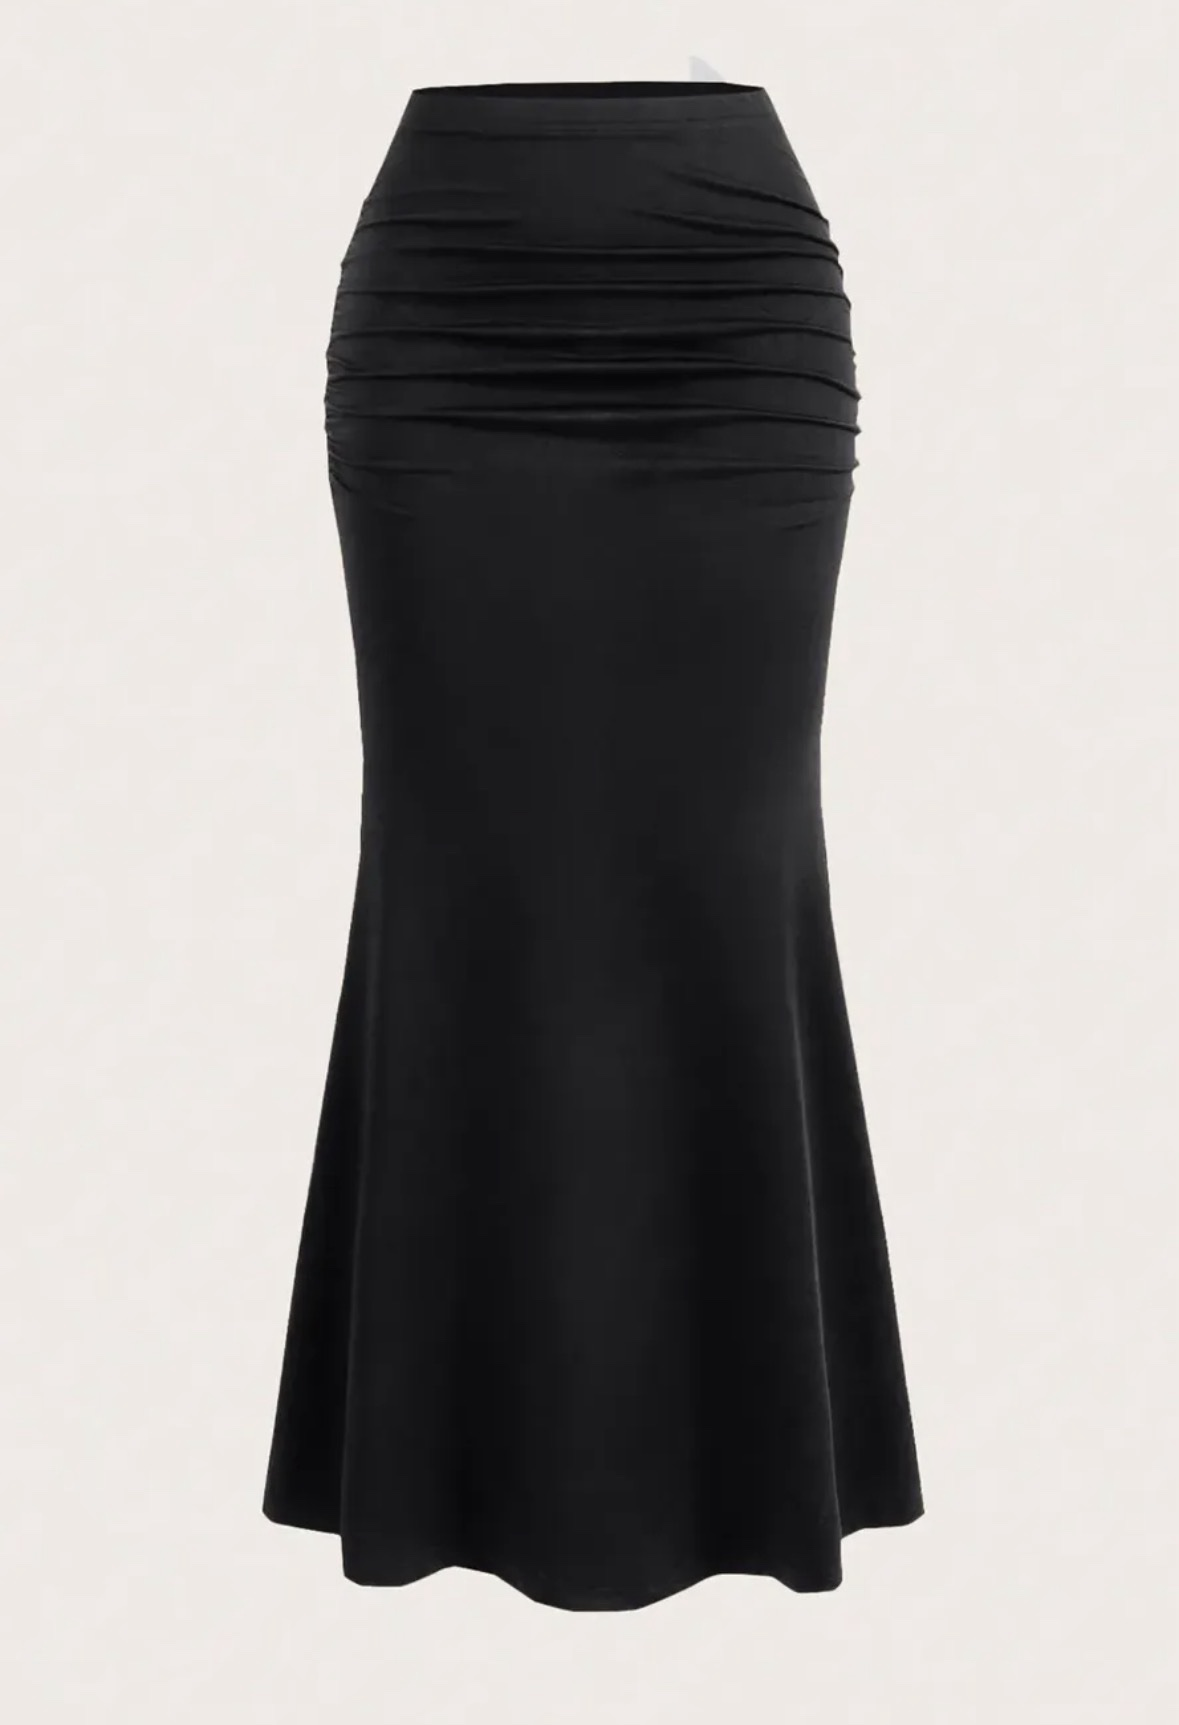

In [69]:
from PIL import Image
from IPython.display import display

# CHANGE THESE TO YOUR NEW FILES
PERSON_PATH = "/kaggle/working/output4.png"
GARMENT_PATH = "/kaggle/working/skirt.jpg"

# Reload the images
person = Image.open(PERSON_PATH).convert("RGB")
garment_rgba = Image.open(GARMENT_PATH).convert("RGBA")

# Create temporary RGB garment for FASHN
background = Image.new(
    "RGB",
    garment_rgba.size,
    (255, 255, 255)
)

background.paste(
    garment_rgba,
    mask=garment_rgba.getchannel("A")
)

garment = background

print("========== CURRENT INPUTS ==========")
print("Person file:", PERSON_PATH)
print("Person size:", person.size)
print("Person mode:", person.mode)

print("\nGarment file:", GARMENT_PATH)
print("Garment size:", garment_rgba.size)
print("Garment original mode:", garment_rgba.mode)
print("Garment sent to FASHN:", garment.mode)

print("\n========== PERSON ==========")
display(person)

print("\n========== GARMENT ==========")
display(garment)

In [70]:
import time
import torch

# Clear previous GPU memory
torch.cuda.empty_cache()

print("=" * 60)
print("STARTING FASHN VTON")
print("=" * 60)

print("GPU:", torch.cuda.get_device_name(0))
print("Person:", person.size)
print("Garment:", garment.size)

start_time = time.perf_counter()

result = pipeline(
    person_image=person,
    garment_image=garment,

    category="bottoms",

    garment_photo_type="flat-lay",

    num_samples=1,

    num_timesteps=30,

    guidance_scale=1.5,

    seed=42,

    segmentation_free=True,
)

torch.cuda.synchronize()

elapsed = time.perf_counter() - start_time

print("\n" + "=" * 60)
print("✅ VTON COMPLETED")
print("=" * 60)

print(f"Inference time: {elapsed:.2f} seconds")
print(f"Generated images: {len(result.images)}")

STARTING FASHN VTON
GPU: Tesla T4
Person: (576, 768)
Garment: (1179, 1725)


TryOnPipeline - INFO - Running inference with 30 timesteps...


Sampling:   0%|          | 0/30 [00:00<?, ?it/s]

TryOnPipeline - INFO - Generated 1 images



✅ VTON COMPLETED
Inference time: 428.99 seconds
Generated images: 1


TRYON


========== VTON RESULT ==========


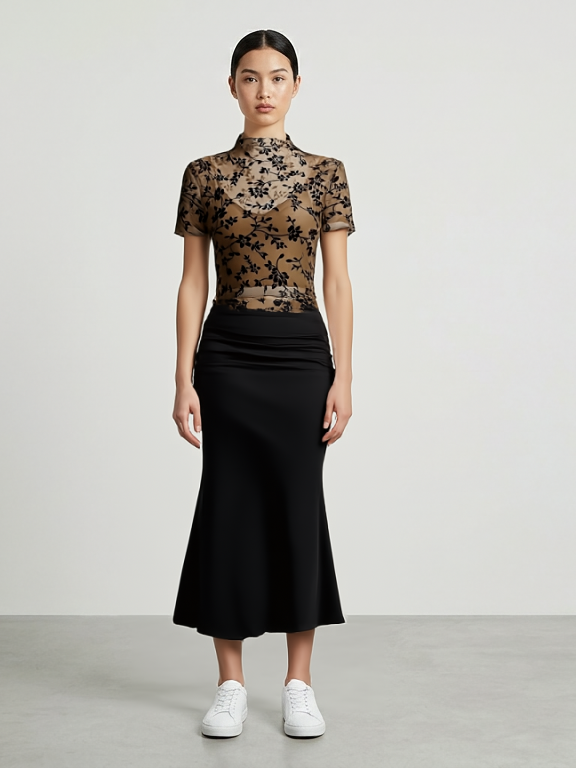

In [71]:
from IPython.display import display

print("========== VTON RESULT ==========")

display(result.images[0])